# 🛰️ ADCS Simulation – Main Notebook

This notebook controls the full simulation process of an Attitude Determination and Control System (ADCS) for a satellite.  
It ties together all the individual modules and provides plots and insights from the simulation results.

---

## 📂 Project Structure Overview

adcs_sim/  
│  
├── main_simulation.ipynb---# Main simulation controller and visualizer  
│  
├── config.py-----------------# Configuration for satellite, orbit, controller  
├── simulation.py------------# Main simulation loop  
│  
├── orbit.py------------------# Orbital motion model  
├── magnetic_field.py-------# Earth's magnetic field model  
├── attitude.py--------------# Attitude dynamics and kinematics  
├── sensors.py---------------# Simulated gyroscope and magnetometer data  
├── controllers.py-----------# ADCS control algorithms (e.g., B-dot)  
├── filters.py----------------# Orientation filters (e.g., complementary, Kalman)  
└── utils.py------------------# Helper functions and coordinate conversions


---

## 📌 Notebook Responsibilities

- Load configuration parameters from `config.py`
- Initialize satellite orbit, orientation, and sensor models
- Execute the simulation loop (`simulation.py`)
- Run control algorithms (e.g., `B-dot` from `controllers.py`)
- Visualize the results (attitude, angular velocity, control actions, etc.)

---

✅ Use this notebook as the **main entry point** for testing different control laws, noise conditions, and filtering techniques.


In [1]:
from sim import simulate
from config import SIMULATION_TIME, SIMULATION_TIMESTEP
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # potrzebne dla 3D
import numpy as np
from utils import quaternion_2_euler

In [2]:
# Run main sim
times, positions, velocities, quaternions, omegas = simulate(SIMULATION_TIME, SIMULATION_TIMESTEP)

In [3]:
times = np.array(times)
positions = np.array(positions)
velocities = np.array(velocities)
quaternions = np.array(quaternions)
omegas = np.array(omegas)

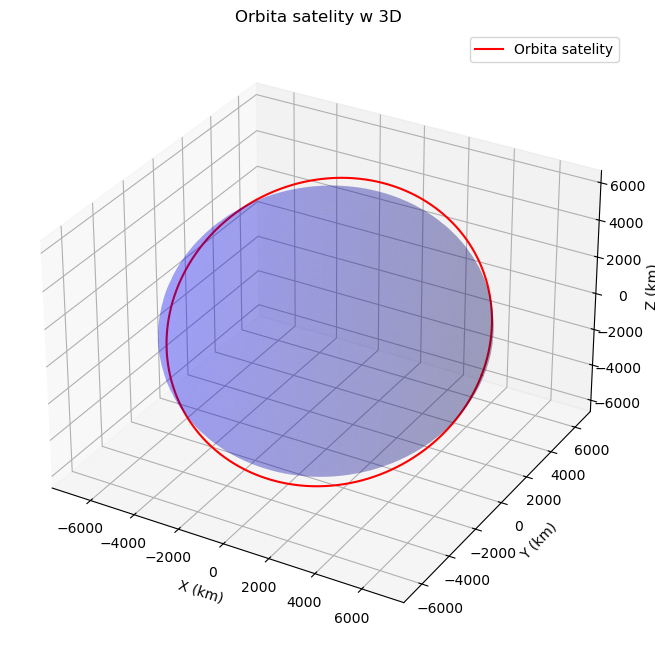

In [4]:
# Tworzenie wykresu
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Wykres orbity
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], label='Orbita satelity', color='red')

# Wykres Ziemi jako kula
R_EARTH = 6378.12  # km
u, v = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
x = R_EARTH * np.outer(np.cos(u), np.sin(v))
y = R_EARTH * np.outer(np.sin(u), np.sin(v))
z = R_EARTH * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='blue', alpha=0.2)

# Ustawienia osi
ax.set_title("Orbita satelity w 3D")
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()
ax.set_box_aspect([1, 1, 0.7])  # Równe proporcje osi
plt.show()

In [5]:
euler = [quaternion_2_euler(x[0], x[1], x[2], x[3]) for x in quaternions]
euler = np.array(euler)

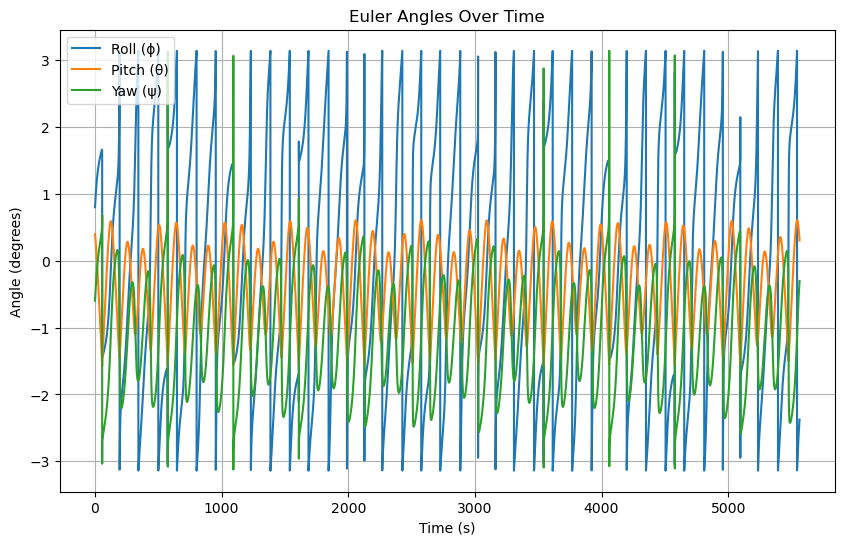

In [6]:
# Plot Euler angles
plt.figure(figsize=(10, 6))
plt.plot(times, euler[:, 0], label='Roll (ϕ)')
plt.plot(times, euler[:, 1], label='Pitch (θ)')
plt.plot(times, euler[:, 2], label='Yaw (ψ)')
plt.title('Euler Angles Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.grid(True)
plt.show()

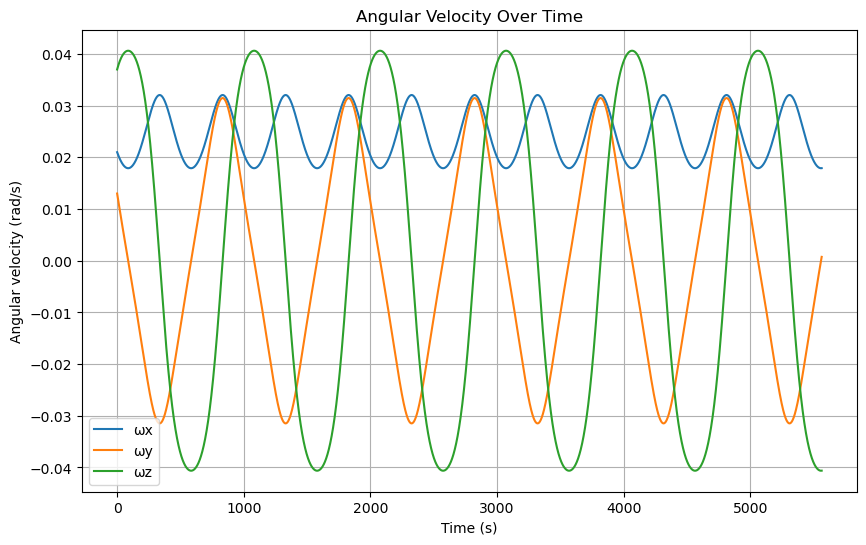

In [7]:
# Angular velocity plot
plt.figure(figsize=(10, 6))
plt.plot(times, omegas[:, 0], label='ωx')
plt.plot(times, omegas[:, 1], label='ωy')
plt.plot(times, omegas[:, 2], label='ωz')
plt.title('Angular Velocity Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angular velocity (rad/s)')
plt.legend()
plt.grid(True)
plt.show()